# Rilevamento delle Fake News
---

In [1]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 3.8 MB/s eta 0:00:00


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from zipfile import ZipFile
from io import BytesIO
import re
import contractions
import spacy
from wordcloud import WordCloud
from gensim.models import Word2Vec
import gensim.downloader
from gensim import corpora
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import LdaModel
from gensim.models import CoherenceModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

## Caricamento del dataset
---

In [3]:
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip"

response = requests.get(url)
if response.status_code == 200:
    zip_file = ZipFile(BytesIO(response.content))
    file_list = zip_file.namelist()

    df_fake = pd.read_csv(zip_file.open(file_list[0]))
    df_true = pd.read_csv(zip_file.open(file_list[1]))

else:
    print("Errore nel download del file:", response.status_code)

In [4]:
df_fake['class'] = 'fake'
df_true['class'] = 'true'

In [7]:
df_fake.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12,fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12,fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12,fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12,fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12,fake


In [8]:
df_true.head()

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12,true
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12,true
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12,true
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12,true
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12,true


Conversione del formato data da stringa a datetime con formato AAAA-MM

In [5]:
def convert_date(date_str):
    possible_formats = ['%B %d, %Y', '%B %d, %Y ', '%b %d, %Y', '%d-%b-%y']
    for fmt in possible_formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

In [6]:
df_true['date'] = df_true['date'].apply(convert_date)
df_fake['date'] = df_fake['date'].apply(convert_date)

df_fake['date'] = df_fake['date'].dt.to_period('M')
df_true['date'] = df_true['date'].dt.to_period('M')

## Analisi del dataset
---

In [9]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype    
---  ------   --------------  -----    
 0   title    23481 non-null  object   
 1   text     23481 non-null  object   
 2   subject  23481 non-null  object   
 3   date     23471 non-null  period[M]
 4   class    23481 non-null  object   
dtypes: object(4), period[M](1)
memory usage: 917.4+ KB


Drop delle 10 righe in cui il valore di 'date' è NULL

In [10]:
df_fake = df_fake.dropna(subset=['date']).reset_index(drop=True)
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23471 entries, 0 to 23470
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype    
---  ------   --------------  -----    
 0   title    23471 non-null  object   
 1   text     23471 non-null  object   
 2   subject  23471 non-null  object   
 3   date     23471 non-null  period[M]
 4   class    23471 non-null  object   
dtypes: object(4), period[M](1)
memory usage: 917.0+ KB


In [11]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype    
---  ------   --------------  -----    
 0   title    21417 non-null  object   
 1   text     21417 non-null  object   
 2   subject  21417 non-null  object   
 3   date     21417 non-null  period[M]
 4   class    21417 non-null  object   
dtypes: object(4), period[M](1)
memory usage: 836.7+ KB


Analisi grafica

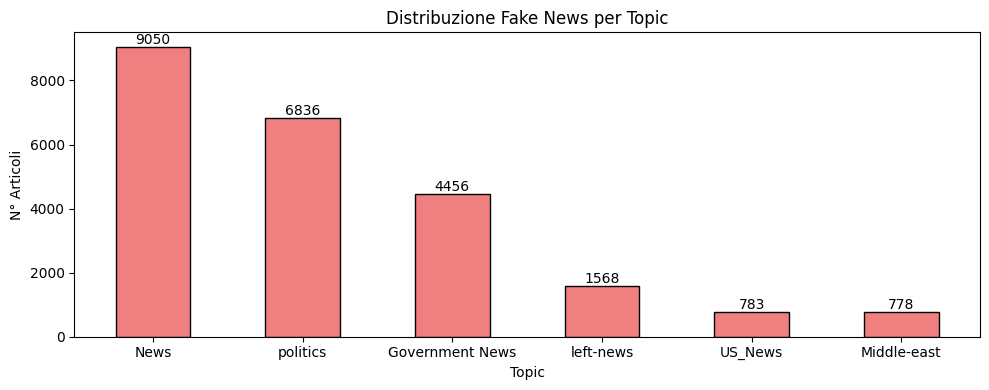

In [12]:
x = df_fake['subject'].unique()
y = df_fake['subject'].value_counts()

plt.figure(figsize=(10,4))
bars = plt.bar(x,y, width=0.5, color='lightcoral', edgecolor='black')
plt.title("Distribuzione Fake News per Topic")
plt.ylabel("N° Articoli")
plt.xlabel("Topic")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Si può notare come la maggior parte delle fake news siano a sfondo politico

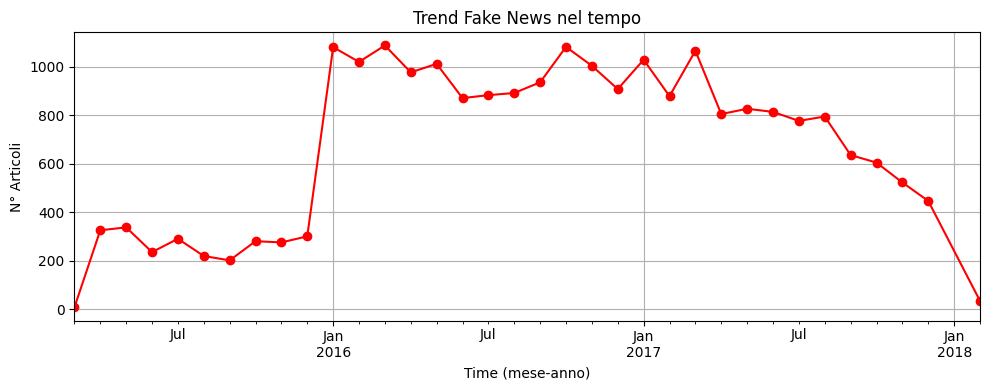

In [13]:
x = df_fake['date'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
x.plot(kind="line", marker='o', color='red')
plt.xlabel('Time (mese-anno)')
plt.ylabel('N° Articoli')
plt.title('Trend Fake News nel tempo')
plt.grid(True)

plt.tight_layout()
plt.show()

L'incremento di fake news nel 2016 è probabilmente correlato alle elezioni presidenziali

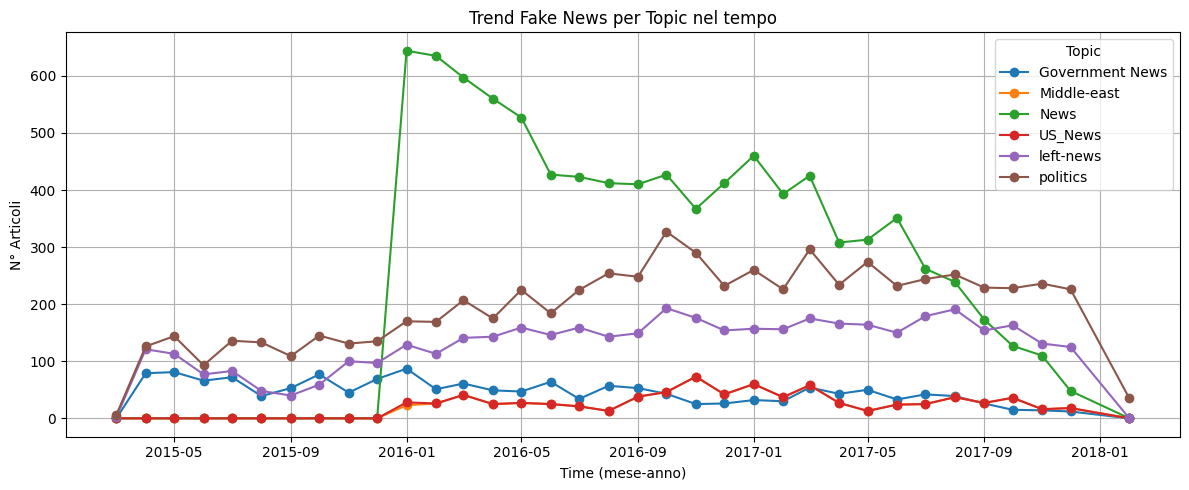

In [14]:
x = df_fake.groupby(['date', 'subject']).size().unstack(fill_value=0)
x.index = x.index.to_timestamp()

plt.figure(figsize=(12, 5))

for subject in x.columns:
    plt.plot(x.index, x[subject], marker='o', label=subject)

plt.xlabel('Time (mese-anno)')
plt.ylabel('N° Articoli')
plt.title('Trend Fake News per Topic nel tempo')
plt.legend(title='Topic')
plt.grid(True)

plt.tight_layout()
plt.show()

## Preprocessing del dataset
----

Definizione di una funzione per la pulizia del testo tramite i seguenti passaggi:
- rimuovere link, caratteri speciali, spazi extra, numeri, punteggiatura e stopword
- espandere le contrazioni
- effettuare la lemmatizzazione

In [15]:
nlp = spacy.load('en_core_web_sm')

In [16]:
def data_cleaner(text):

    text = contractions.fix(text)

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp(text.lower())

    cleaned_text = [token.lemma_ for token in doc
                    if not token.is_stop and token.is_alpha and len(token)>=3]

    return ' '.join(cleaned_text)


Pulizia e unione dei dataset

In [ ]:
df = pd.concat([df_fake, df_true], ignore_index=True)

df['title'] = df['title'].apply(data_cleaner)
df['text'] = df['text'].apply(data_cleaner)
df['class'] = df['class'].map({'fake': 0, 'true': 1})

df.head()


,title,text,subject,date,class
0,donald trump send embarrass year message disturb,donald trump couldn wish americans happy year ...,News,2017-12,0
1,drunk bragging trump staffer start russian col...,house intelligence committee chairman devin nu...,News,2017-12,0
2,sheriff david clarke internet joke threaten po...,friday reveal milwaukee sheriff david clarke c...,News,2017-12,0
3,trump obsessed obama code website image,christmas donald trump announce work following...,News,2017-12,0
4,pope francis call donald trump christmas speech,pope francis annual christmas message rebuke d...,News,2017-12,0


Word Embedding

In [21]:
w2v_model = gensim.downloader.load('word2vec-google-news-300')

def w2v_embedding(text):
    vectors = [w2v_model.get_vector(word)
              for word in text
              if word in w2v_model.key_to_index]

    return np.mean(vectors, axis=0) if vectors else np.zeros(w2v_model.vector_size)


In [22]:
df_w2v = pd.DataFrame()
df_w2v['content'] = df['title'] + ' ' + df['text']
df_w2v['embedding'] = df_w2v['content'].apply(w2v_embedding)
df_w2v['class'] = df['class']

## Classificatore
---

Dataset train e test

In [23]:
X = list(df_w2v['embedding'])
y = df_w2v['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

#### Logistic Regression

In [25]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      4638
           1       0.73      0.69      0.71      4340

    accuracy                           0.72      8978
   macro avg       0.72      0.72      0.72      8978
weighted avg       0.72      0.72      0.72      8978



#### Random Forest Classifier

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=9)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83      4638
           1       0.84      0.79      0.81      4340

    accuracy                           0.82      8978
   macro avg       0.82      0.82      0.82      8978
weighted avg       0.82      0.82      0.82      8978



Utilizzando il dataset (diviso in train e test) si realizza un **classificatore** in grado di stabilire se un articolo è una fake news. Si sceglie il modello realizzato con l'algoritmo Random Forest, che presenta risultati migliori rispetto al Regressore Logistico.

## Topic modeling
---

Stabilire i topic più frequenti all'interno delle fake news utilizzando la tecnica LDA

In [29]:
fake_df = pd.DataFrame()

fake_df['content'] = df_w2v[df_w2v['class']==0]['content']
fake_df['tokens'] = fake_df['content'].apply(lambda x: [word for word in x.split()])

dictionary = corpora.Dictionary(fake_df['tokens'])
corpus = [dictionary.doc2bow(text) for text in fake_df['tokens']]

In [30]:
lda_model = LdaModel(corpus, num_topics=13, id2word=dictionary, passes=10, random_state=9)

coherence_model_lda = CoherenceModel(model=lda_model, texts=fake_df['tokens'], dictionary=dictionary, coherence='c_v')
print(f"Coherence Score: {coherence_model_lda.get_coherence()}")

Coherence Score: 0.4642358552417027


Analisi dei topic trovati

Topic 1: 0.018*"hollywood" + 0.014*"rubio" + 0.014*"film" + 0.012*"white" + 0.011*"video"
Topic 2: 0.017*"student" + 0.016*"school" + 0.013*"say" + 0.011*"court" + 0.009*"university"
Topic 3: 0.019*"medium" + 0.019*"news" + 0.012*"story" + 0.011*"report" + 0.010*"wire"
Topic 4: 0.064*"clinton" + 0.048*"hillary" + 0.020*"campaign" + 0.017*"election" + 0.017*"email"
Topic 5: 0.110*"trump" + 0.023*"donald" + 0.017*"say" + 0.015*"president" + 0.010*"people"
Topic 6: 0.017*"syria" + 0.013*"military" + 0.010*"say" + 0.010*"state" + 0.008*"iran"
Topic 7: 0.019*"president" + 0.016*"obama" + 0.016*"say" + 0.015*"house" + 0.013*"department"
Topic 8: 0.014*"state" + 0.012*"million" + 0.011*"vote" + 0.008*"year" + 0.008*"percent"
Topic 9: 0.021*"obama" + 0.013*"president" + 0.011*"america" + 0.010*"people" + 0.009*"american"
Topic 10: 0.025*"muslim" + 0.018*"terrorist" + 0.016*"refugee" + 0.014*"isis" + 0.013*"illegal"
Topic 11: 0.021*"room" + 0.018*"boiler" + 0.014*"water" + 0.012*"radio" + 0.012

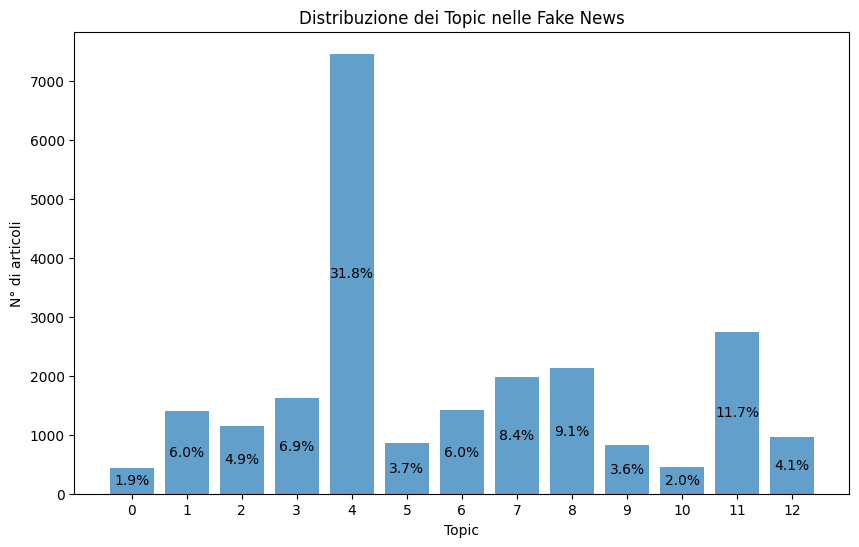

In [33]:
topics = lda_model.print_topics(num_words=5)

for id, topic in topics:
    print(f"Topic {id}: {topic}")

fake_df['dominant_topic'] = [max(lda_model[corpus[i]], key=lambda x: x[1])[0] for i in range(len(corpus))]

topic_distribution = fake_df['dominant_topic'].value_counts().sort_index()
topic_percentage = (topic_distribution / len(fake_df)) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(topic_distribution.index, topic_distribution.values, alpha=0.7)

for bar, percentage in zip(bars, topic_percentage.values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f'{percentage:.1f}%',
        ha='center', va='center', color='black', fontsize=10)

ax.set_xlabel('Topic')
ax.set_ylabel('N° di articoli')
ax.set_xticks(topic_distribution.index)
plt.title('Distribuzione dei Topic nelle Fake News')

plt.show()

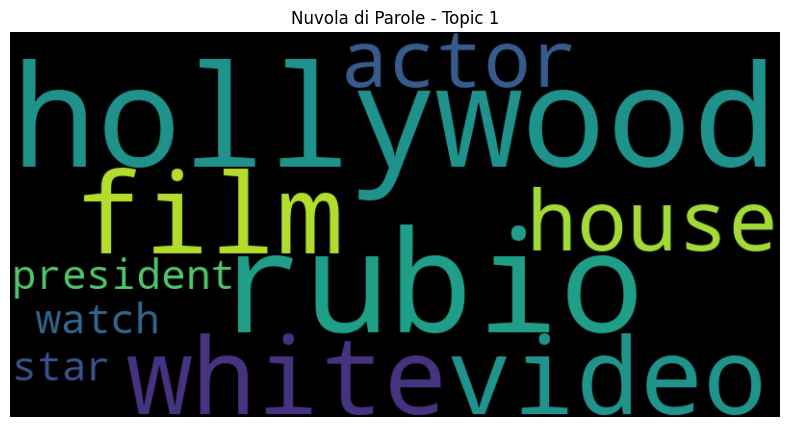

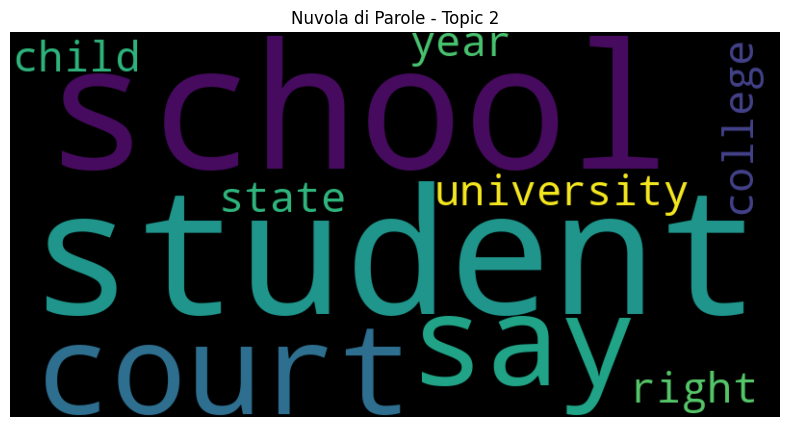

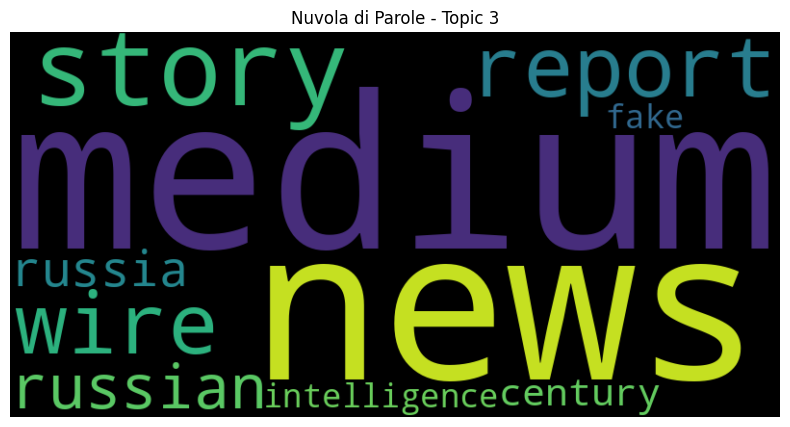

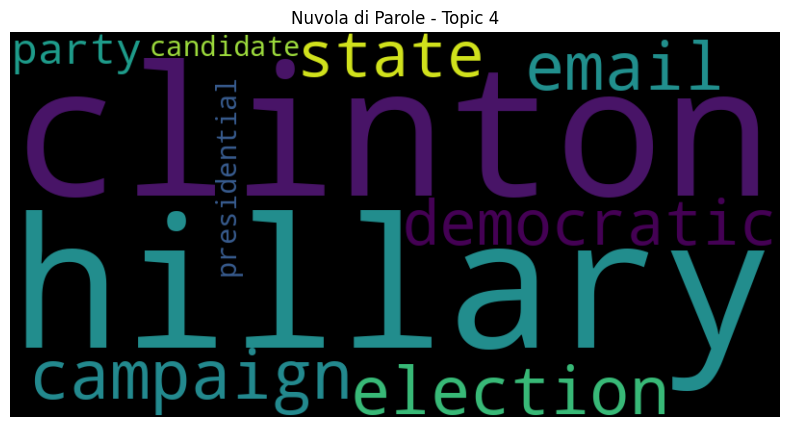

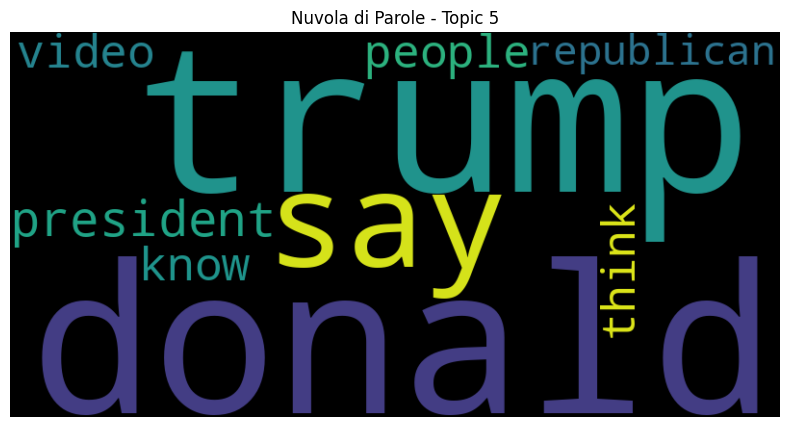

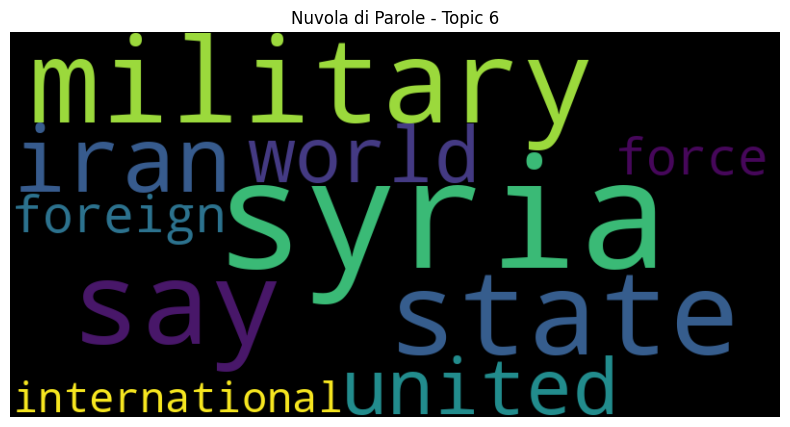

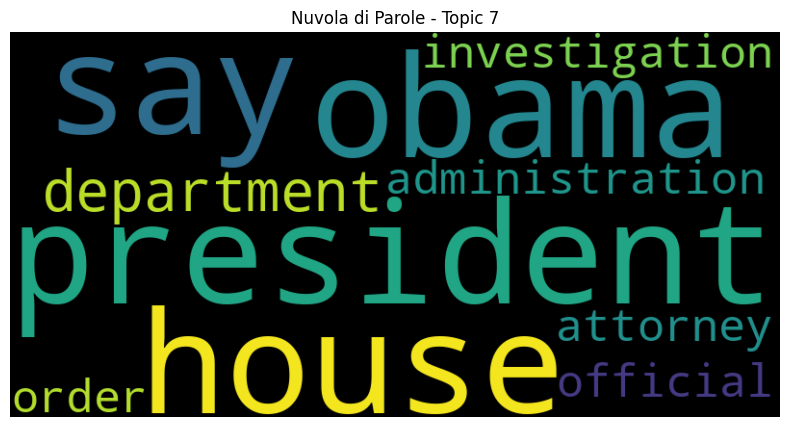

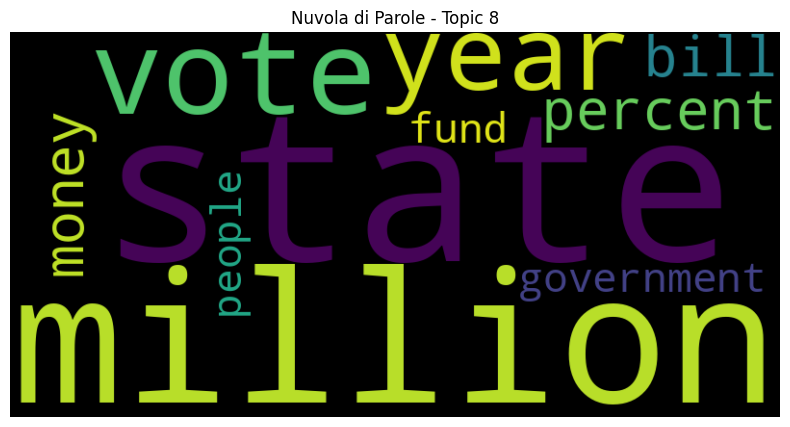

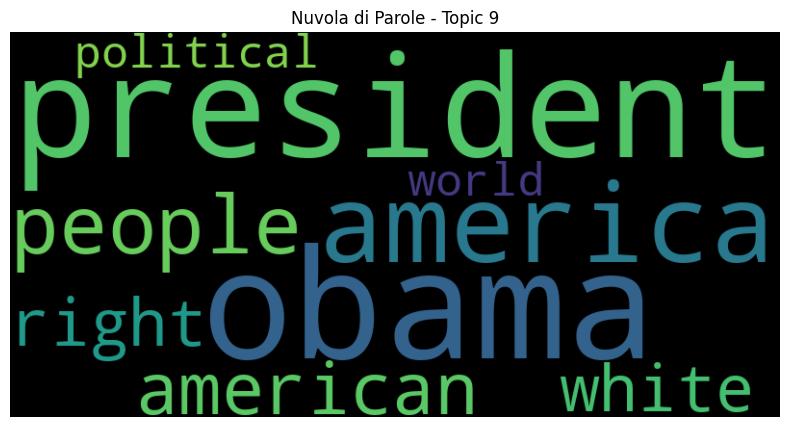

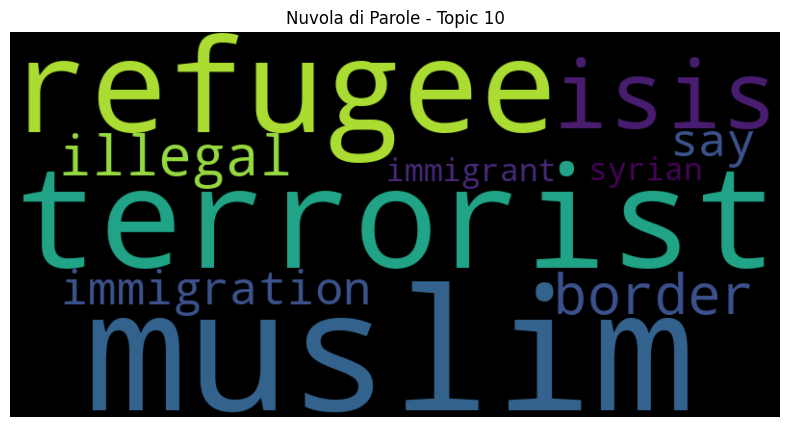

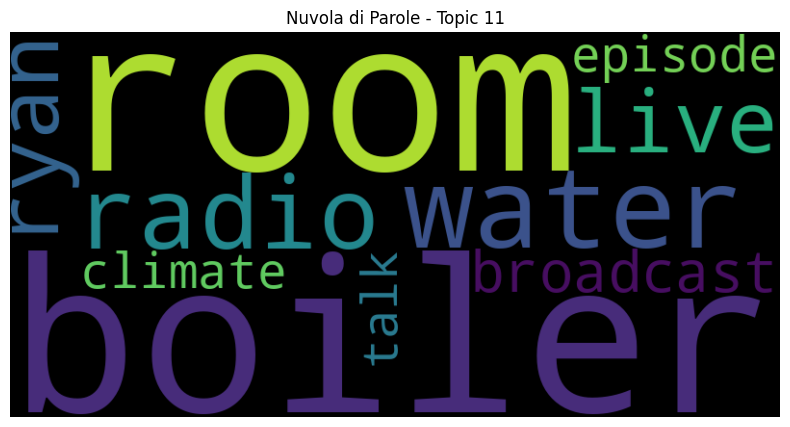

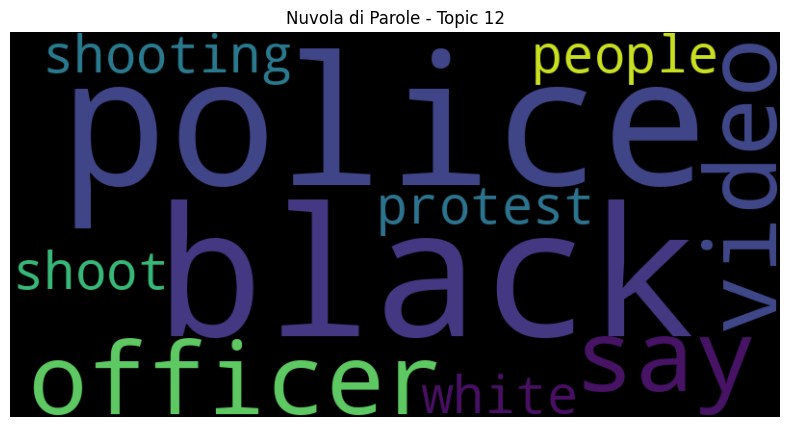

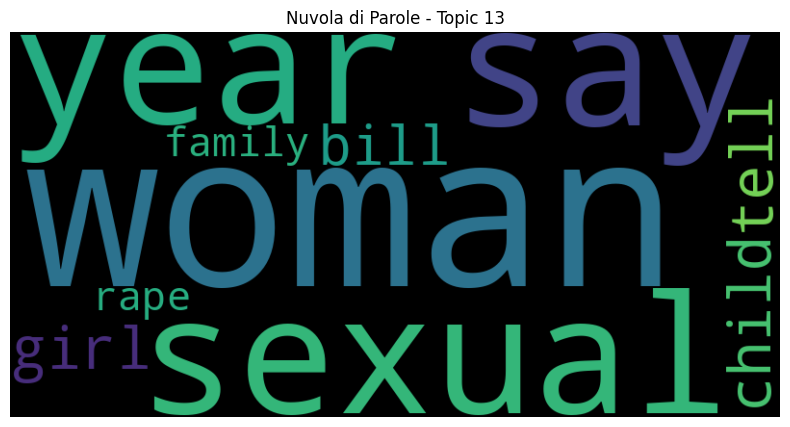

In [35]:
topics = lda_model.show_topics(num_topics=13, num_words=10, formatted=False)

topic_words = {f'Topic {i+1}': [word for word, _ in topic] for i, topic in topics}

for id, words in topic_words.items():
    wordcloud = WordCloud(width=800, height=400).generate(" ".join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Nuvola di Parole - {id}")
    plt.show()

## Pattern titoli

Determinare pattern nei titoli delle fake news analizzando le parole più ricorrenti

In [42]:
fake_news_titles = df[df['class']==0]['title']

vectorizer = CountVectorizer(max_features=20)
title_word_counts = vectorizer.fit_transform(fake_news_titles)

common_words = vectorizer.get_feature_names_out()
common_word_counts = title_word_counts.toarray().sum(axis=0)

common_words_with_counts = list(zip(common_words, common_word_counts))

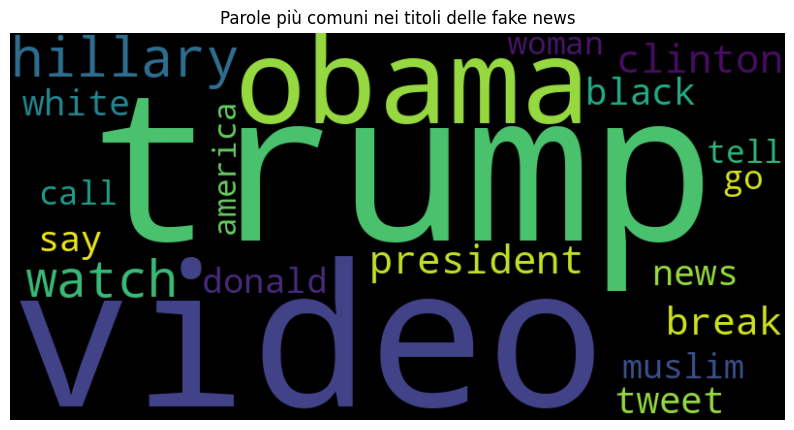

In [43]:
word_freq_dict = dict(common_words_with_counts)

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Parole più comuni nei titoli delle fake news")
plt.show()

Determinare pattern nei titoli analizzando bigrammi e trigrammi

In [44]:
vectorizer_ngrams = CountVectorizer(ngram_range=(2, 3), max_features=20)
title_ngrams_counts = vectorizer_ngrams.fit_transform(fake_news_titles)

common_ngrams = vectorizer_ngrams.get_feature_names_out()
common_ngram_counts = title_ngrams_counts.toarray().sum(axis=0)

common_ngrams_with_counts = list(zip(common_ngrams, common_ngram_counts))

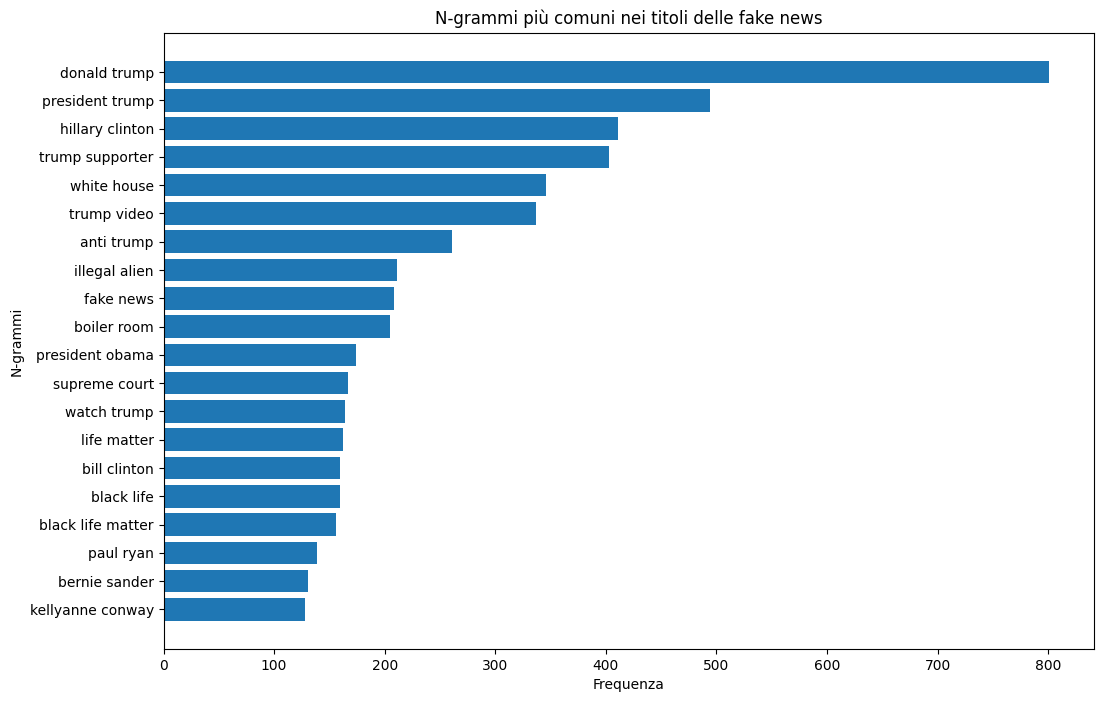

In [45]:
sorted_ngrams = sorted(common_ngrams_with_counts, key=lambda x: x[1], reverse=True)
ngrams, counts = zip(*sorted_ngrams)

plt.figure(figsize=(12, 8))
plt.barh(ngrams, counts)
plt.xlabel("Frequenza")
plt.ylabel("N-grammi")
plt.title("N-grammi più comuni nei titoli delle fake news")
plt.gca().invert_yaxis()
plt.show()

Si può notare dai grafici ottenuti come le fake news più comuni trattano argomenti riguardanti i presidenti degli Stati Uniti